In [1]:
import gzip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import Bio
import Bio.SeqIO as SeqIO

import joblib
memory = joblib.Memory("./cache/", verbose=0)

In [2]:
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
print(f">> WT Length = {len(WT_DNA)}")

def hamming_dist(str1, str2=WT_DNA):
    ret = -1
    if len(str1) == len(str2):
        ret = sum(s1 != s2 for s1, s2 in zip(str1, str2))
    return ret

def pp_diff(str1, str2=WT_DNA):
    if len(str1) != len(str2):
        print ("Strings have different lengths")
    for i, (s1, s2) in enumerate(zip(str1, str2)):
        if s1 != s2:
            print(f"At {i:03d} : nt1= {s1}, nt2 = {s2} ")

>> WT Length = 822


In [3]:
@memory.cache
def get_raw_df(filename):
    records = []
    with gzip.open(filename, "rt") as handle:
        records = list(SeqIO.parse(handle, "fasta")) 
    df =  pd.DataFrame([{'id':r.id, 'seq':str(r.seq)} for r in records])    
    df["dist_from_wt"] = df.seq.apply(hamming_dist)
    return df

df = get_raw_df("./data/bc1036-no-indel.fa.gz")
Nraw = len(df)
print(f">> Number of raw sequences : {Nraw}")

>> Number of raw sequences : 168743


In [4]:
id_split = df.id.str.split("/", expand=True)
id_split.columns = ["batch_id", "seqid", "ccs", "direction"]
del id_split["batch_id"] # there should be only one
del id_split["ccs"] # this is ccs everywhere
id_split.head()

,seqid,direction
0,194,fwd
1,194,rev
2,279,fwd
3,279,rev
4,428,fwd


In [5]:
df["seqid"] = id_split["seqid"]
df["direction"] = id_split["direction"]
df["length"] = df.seq.str.len()
del df["id"]
df["seqid"] = df.seqid.astype(np.int64)
df["dir_count"] = df.groupby('seqid')['direction'].transform('size')
df.head()

,seq,dist_from_wt,seqid,direction,length,dir_count
0,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,1,194,fwd,822,2
1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,4,194,rev,822,2
2,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,0,279,fwd,822,2
3,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,4,279,rev,822,2
4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,6,428,fwd,822,2


In [6]:
df.dir_count.value_counts()

2    84784
1    83959
Name: dir_count, dtype: int64

In [7]:
# filter out sequences that do not have the same length as WT
df_filter = df[df.length == len(WT_DNA)].copy()
print(f">> Percentage of sequences retained : {len(df_filter)  / len(df) * 100:.2f}%")

>> Percentage of sequences retained : 98.86%


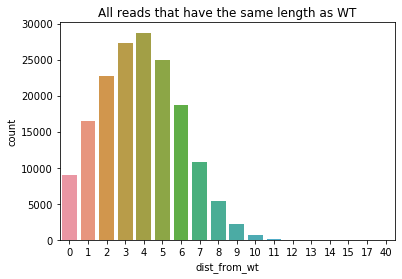

In [8]:
sns.countplot(x="dist_from_wt", data=df_filter).set_title("All reads that have the same length as WT");

In [9]:
df[df.seqid == 67166]

,seq,dist_from_wt,seqid,direction,length,dir_count
48,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,4,67166,rev,822,2
168098,GCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCA...,-1,67166,fwd,820,2


In [10]:
paired_df = df_filter[df_filter.dir_count == 2].copy()

# Check whether seqid and direction gives us a unique sequence
# i.e. we don't have two or more sequences with the same id in the same direction
assert(paired_df.groupby(["seqid", "direction"]).size() == 1).all()

# number of paired sites left after filtering
# this will be different from dir_count (since filtering has been done)
paired_df["psize"] = paired_df.groupby(["seqid"])["direction"].transform('size')
paired_df = paired_df[paired_df.psize == 2]

paired_df.head()

,seq,dist_from_wt,seqid,direction,length,dir_count,psize
0,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,1,194,fwd,822,2,2
1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,4,194,rev,822,2,2
2,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,0,279,fwd,822,2,2
3,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,4,279,rev,822,2,2
4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,6,428,fwd,822,2,2


In [11]:
paired_df.direction.value_counts()

fwd    41555
rev    41555
Name: direction, dtype: int64

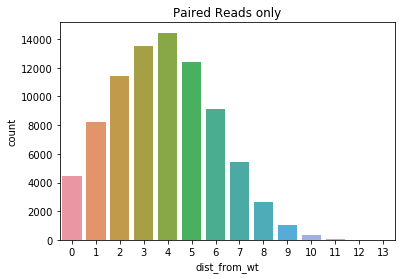

In [12]:
sns.countplot(x="dist_from_wt", data=paired_df).set_title("Paired Reads only");

In [13]:
NT_MAP = {n:i for i, n in enumerate(list("ACTG"))}
NT_MAP

{'A': 0, 'C': 1, 'T': 2, 'G': 3}

In [14]:
NT_MAP_REV = {v:k for k,v in NT_MAP.items()}
NT_MAP_REV

{0: 'A', 1: 'C', 2: 'T', 3: 'G'}

In [15]:
np_seqs = np.array([[NT_MAP[s] for s in seq] for seq in paired_df.seq], dtype=np.int8)
np_seqs.shape

(83110, 822)

In [16]:
wt_index = np.where(paired_df.dist_from_wt == 0)[0][0]
WT_np = np_seqs[wt_index, :]

In [17]:
fwd_mask = (paired_df.direction == "fwd")

In [18]:
np_fwd = np_seqs[fwd_mask, :]
np_rev = np_seqs[~fwd_mask, :]

In [19]:
fwd_rev_disagree_mask = (np_fwd != np_rev)
fwd_rev_disagree_mask.shape

(41555, 822)

In [20]:
seq_id_disagree, pos_id_disagree = np.where(fwd_rev_disagree_mask)

corrected_seqs = np_fwd.copy()
corrected_seqs[seq_id_disagree, pos_id_disagree] = WT_np[pos_id_disagree]
corrected_seqs.shape

(41555, 822)

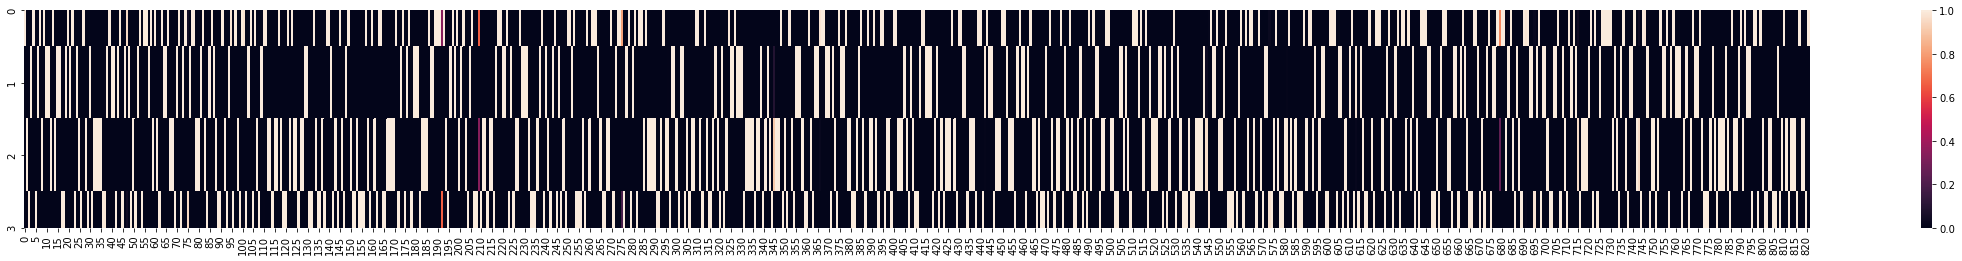

In [21]:
# Convert to one-hot sequences
corrected_seqs_one_hot = np.zeros(corrected_seqs.shape + (len(NT_MAP),), dtype=np.int8)

for i in NT_MAP.values():
    corrected_seqs_one_hot[:, :, i] = (corrected_seqs == i)

corrected_seqs_one_hot.shape

plt.figure(figsize=(40, 4))
sns.heatmap(corrected_seqs_one_hot.mean(axis=0).transpose())

In [22]:
unique_seqs, unique_seq_counts = np.unique(corrected_seqs, axis=0, return_counts=True)
unique_seqs.shape

(3627, 822)

In [23]:
unique_seqs_str = np.apply_along_axis(lambda x: "".join(NT_MAP_REV[i] for i in x), axis=1, arr=unique_seqs)

In [24]:
unique_seqs_pd = pd.DataFrame({"seqs":unique_seqs_str, "seq_count":unique_seq_counts, 
                               "dist_from_wt":(unique_seqs != WT_np).sum(axis=1)})

unique_seqs_pd.sort_values("seq_count", ascending=True, inplace=True)

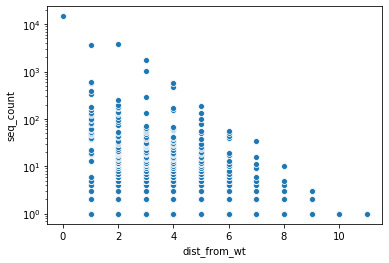

In [28]:
sns.scatterplot(unique_seqs_pd.dist_from_wt, unique_seqs_pd.seq_count)
plt.yscale("log")

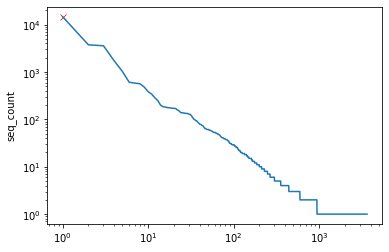

In [26]:
unique_seq_indexing = np.flip(np.arange(len(unique_seqs_pd)) + 1)
unique_wt_mask = unique_seqs_pd.dist_from_wt == 0
sns.lineplot(unique_seq_indexing, unique_seqs_pd.seq_count)
sns.scatterplot(unique_seq_indexing[unique_wt_mask],
                unique_seqs_pd.seq_count[unique_wt_mask], marker='x', color="red")
plt.yscale('log')
plt.xscale('log')